# Customer Segmentation using K-Means Clustering
End-to-end notebook using the Mall Customers dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

plt.style.use("ggplot")


## 2. Loading Dataset

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Basic Exploration

In [4]:
print("Shape:", df.shape)
display(df.info())
display(df.describe(include="all"))
print("\nMissing Values")
display(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


None

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000



Missing Values


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Duplicate Rows: 0


## 4. Exploratory Data Analysis

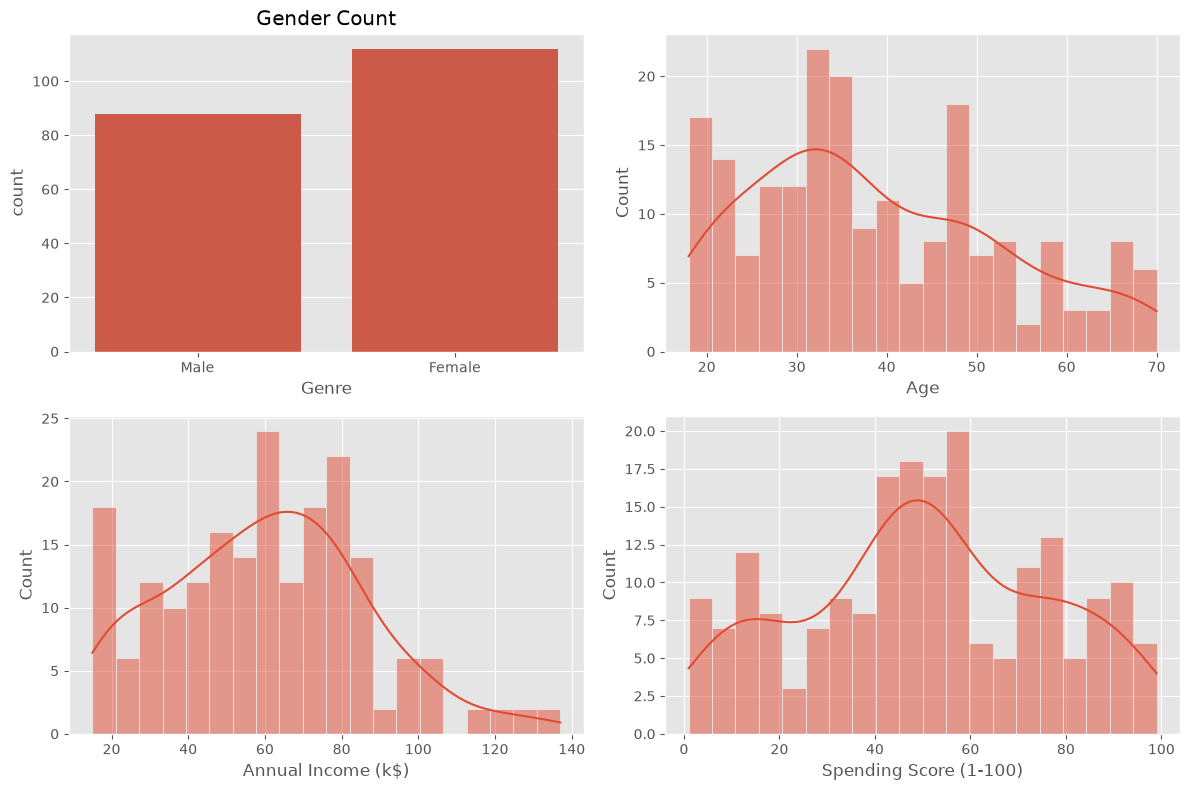

In [5]:
fig,ax=plt.subplots(2,2,figsize=(12,8))

sns.countplot(data=df,x="Genre",ax=ax[0,0])
ax[0,0].set_title("Gender Count")

sns.histplot(df["Age"],bins=20,kde=True,ax=ax[0,1])

sns.histplot(df["Annual Income (k$)"],bins=20,kde=True,ax=ax[1,0])

sns.histplot(df["Spending Score (1-100)"],bins=20,kde=True,ax=ax[1,1])

plt.tight_layout()
plt.show()

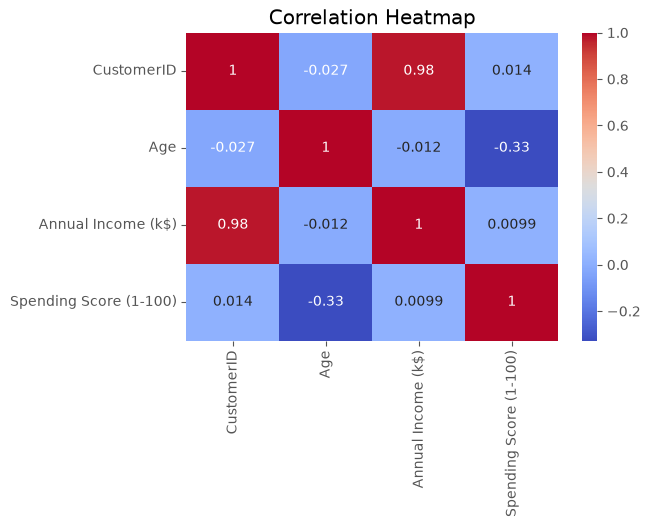

In [6]:
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 5. Data Preprocessing

In [7]:
df = df.drop(columns=["CustomerID"])

encoder = LabelEncoder()
df["Genre"] = encoder.fit_transform(df["Genre"])

feature_columns = df.columns.tolist()

X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled,columns=feature_columns).head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


## 6. Elbow Method

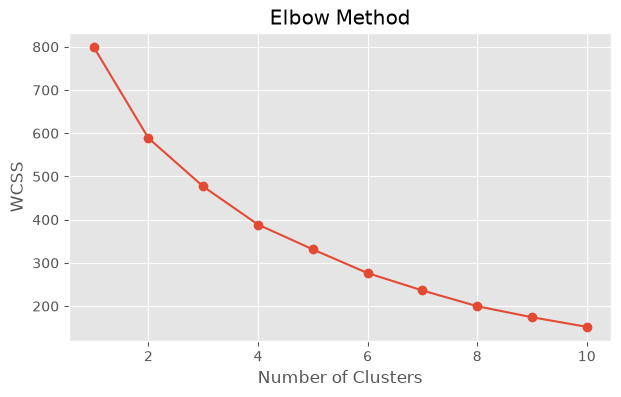

In [8]:
wcss=[]

for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42,n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## 7. Train KMeans Model

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head(10)

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,3
1,1,21,15,81,3
2,0,20,16,6,3
3,0,23,16,77,3
4,0,31,17,40,3
5,0,22,17,76,3
6,0,35,18,6,2
7,0,23,18,94,3
8,1,64,19,3,4
9,0,30,19,72,3


## 8. Silhouette Score

In [11]:
score = silhouette_score(X_scaled,clusters)
print("Silhouette Score:",round(score,3))

Silhouette Score: 0.304


## 9. Cluster Visualization

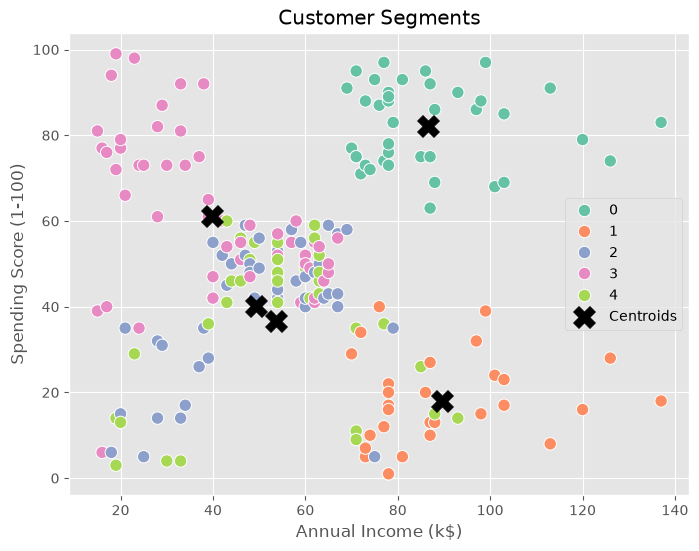

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=80
)

centers=scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:,2],
    centers[:,3],
    c="black",
    s=250,
    marker="X",
    label="Centroids"
)

plt.legend()
plt.title("Customer Segments")
plt.show()

## 10. Save Model

In [14]:
model_data = {
    "model": kmeans,
    "scaler": scaler,
    "label_encoder": encoder,
    "feature_columns": feature_columns
}

joblib.dump(model_data,"kmeans.pkl")
print("Model saved successfully.")

Model saved successfully.


## 11. Predict Cluster for a New Customer

In [15]:
gender="Male"
age=28
income=60
score=70

gender=encoder.transform([gender])[0]

sample=pd.DataFrame([[gender,age,income,score]],columns=feature_columns)

sample_scaled=scaler.transform(sample)

cluster=kmeans.predict(sample_scaled)[0]

cluster_names={
    0:"Customer Segment 0",
    1:"Customer Segment 1",
    2:"Customer Segment 2",
    3:"Customer Segment 3",
    4:"Customer Segment 4"
}

print("Predicted Cluster:",cluster)
print(cluster_names[cluster])

Predicted Cluster: 3
Customer Segment 3
